<a href="https://colab.research.google.com/github/sanjanascorner/PyTorch-and-DeepLearning/blob/main/RCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
!unzip -q PennFudanPed.zip

--2026-09-11 03:00:53--  https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
Resolving www.cis.upenn.edu (www.cis.upenn.edu)... 158.130.69.163, 2607:f470:8:64:5ea5::d
Connecting to www.cis.upenn.edu (www.cis.upenn.edu)|158.130.69.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53723336 (51M) [application/zip]
Saving to: ‘PennFudanPed.zip.3’

PennFudanPed.zip.3  100%[===================>]  51.23M  26.5MB/s    in 1.9s    

2026-09-11 03:00:55 (26.5 MB/s) - ‘PennFudanPed.zip.3’ saved [53723336/53723336]

replace PennFudanPed/added-object-list.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import numpy as np
import os
import time
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
!pip install opencv-contrib-python

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset,random_split
from torchvision import transforms as T,models

In [ ]:
import os

root = "PennFudanPed"
images_path = sorted(os.listdir(os.path.join(root, "PNGImages")))
masks_path = sorted(os.listdir(os.path.join(root, "PedMasks")))
print(f"Images: {len(images_path)}, Masks: {len(masks_path)}")
print(images_path[:3], masks_path[:3])


Images: 170, Masks: 170
['FudanPed00001.png', 'FudanPed00002.png', 'FudanPed00003.png'] ['FudanPed00001_mask.png', 'FudanPed00002_mask.png', 'FudanPed00003_mask.png']


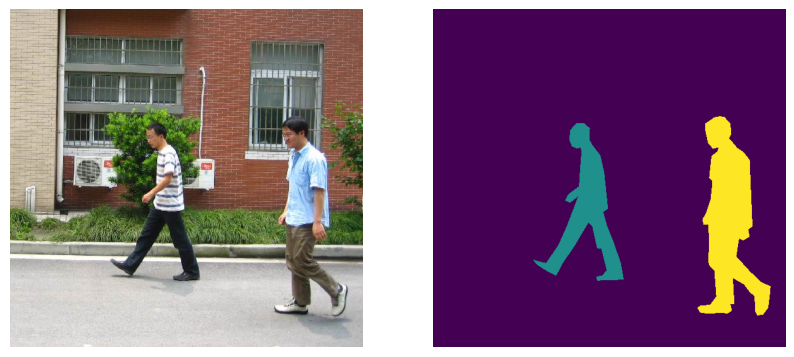

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

i=0
image_full_path = os.path.join(root, "PNGImages", images_path[i])
mask_full_path = os.path.join(root, "PedMasks", masks_path[i])
figure,axes=plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(Image.open(image_full_path))
axes[1].imshow(Image.open(mask_full_path))
axes[0].axis('off')
axes[1].axis('off')
plt.show()

In [ ]:
def get_bounding_boxes(mask,label): #will get bounding box for that particular label
#0 is for background,#1 is for a person #2 is another person.
#mask's pixels will have similar values.
  obj=np.where(mask==label)
  y1,y2=obj[0].min(),obj[0].max()
  x1,x2=obj[1].min(),obj[1].max()
  return {'x1':x1,'y1':y1,'x2':x2,'y2':y2}
def get_patch(bbox):
    width=bbox['x2']-bbox['x1']
    height=bbox['y2']-bbox['y1']
    x,y=bbox['x1'],bbox['y1']
    rectangle=patches.Rectangle((x,y),width,height,linewidth=1,edgecolor='r',facecolor='none')
    return rectangle



In [ ]:
def get_annotations(mask):
    labels=np.unique(mask)
    annotations=[]
    for label in labels:
        if label>0:
           annotations.append(get_bounding_boxes(mask,label))
    return annotations
#takes unique pixel values from mask and iterating it through, we get bounding box coordinates for pedestrians

In [ ]:
import os
from PIL import Image
import numpy as np

mask_full_path = os.path.join(root, "PedMasks", masks_path[3])
mask=np.array(Image.open(mask_full_path))
print(mask)
annotations=get_annotations(mask)
print(annotations)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[{'x1': np.int64(167), 'y1': np.int64(59), 'x2': np.int64(323), 'y2': np.int64(337)}, {'x1': np.int64(8), 'y1': np.int64(60), 'x2': np.int64(47), 'y2': np.int64(179)}]


In [ ]:
def get_bbox_area(bbox):
  w=bbox['x2']-bbox['x1']
  h=bbox['y2']-bbox['y1']
  return h*w
def get_iou(bbox1,bbox2):
    x_left=max(bbox1['x1'],bbox2['x1'])
    x_right=min(bbox1['x2'],bbox2['x2'])
    y_top=max(bbox1['y1'],bbox2['y1'])
    y_bottom=min(bbox1['y2'],bbox2['y2'])
    if x_right<x_left or y_bottom<y_top:
        return 0.0
    intersection_area=abs(x_right-x_left)*abs(y_bottom-y_top)
    bbox1_area=(bbox1['x2']-bbox1['x1'])*(bbox1['y2']-bbox1['y1'])
    bbox2_area=(bbox2['x2']-bbox2['x1'])*(bbox2['y2']-bbox2['y1'])
    iou=float(intersection_area)/(bbox1_area+bbox2_area-intersection_area)
    return iou



In [ ]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless opencv-contrib-python-headless
!pip install opencv-contrib-python

Found existing installation: opencv-contrib-python 5.0.0.93
Uninstalling opencv-contrib-python-5.0.0.93:
  Successfully uninstalled opencv-contrib-python-5.0.0.93
  Using cached opencv_contrib_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_contrib_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (82.1 MB)


In [ ]:
import cv2

In [ ]:
selSearch=cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
def get_regions(image):
    selSearch.setBaseImage(image)
    selSearch.switchToSelectiveSearchFast()
    regions=selSearch.process()
    return regions
def compute_offset(g, p):
    px, py, pw, ph = p['x1'], p['y1'], p['x2'] - p['x1'], p['y2'] - p['y1']
    gx, gy, gw, gh = g['x1'], g['y1'], p['x2'] - g['x1'], p['y2'] - g['y1']
    dx = (gx - px) / pw
    dy = (gy - py) / ph
    dw = np.log(gw / pw)
    dh = np.log(gh / ph)
    return [dx, dy, dw, dh]
def prepare_training_data(images_path,target_path):
    training_images=[]
    training_labels=[]
    training_bboxes=[]
    length=len(images_path)
    # Using a fixed seed for reproducibility
    np.random.seed(42)

    for i in range(length):
      print("Processing image",i+1)
      image_full_path = os.path.join(root, "PNGImages", images_path[i])
      mask_full_path = os.path.join(root, "PedMasks", target_path[i])

      image=np.array(Image.open(image_full_path))
      mask=np.array(Image.open(mask_full_path))
      annotations=get_annotations(mask) # Ground truth bounding boxes
      regions=get_regions(image) # Proposed regions from selective search
      imout=image.copy()

      t_counter=0 # Counter for positive samples
      f_counter=0 # Counter for negative samples

      # Shuffle regions to avoid bias from the order of selective search
      np.random.shuffle(regions)

      for region in regions:
          # Stop processing regions for this image if we have enough samples
          if t_counter >= 30 and f_counter >= 12:
              break

          x,y,w,h = region
          # Ensure region coordinates are within image bounds
          x_end, y_end = x + w, y + h
          if x < 0 or y < 0 or x_end > image.shape[1] or y_end > image.shape[0]:
              continue # Skip regions outside image bounds

          bbox2={'x1':x,'y1':y,'x2':x_end,'y2':y_end} # Proposed region

          ious = []
          if len(annotations) > 0:
              ious=[get_iou(bbox1,bbox2) for bbox1 in annotations]
              max_iou = np.max(ious)
          else:
              max_iou = 0.0 # No ground truth, so IOU is 0

          # Positive samples: IoU >= 0.5 with any ground truth box
          if max_iou >= 0.5 and t_counter < 30:
             gt_idx = np.argmax(ious)
             gt = annotations[gt_idx]
             offset = compute_offset(gt, bbox2) # Compute offset between gt and proposed bbox2

             roi=imout[bbox2['y1']:bbox2['y2'],bbox2['x1']:bbox2['x2']]
             roi=cv2.resize(roi,(224,224),interpolation=cv2.INTER_AREA)
             training_images.append(roi)
             training_bboxes.append(offset)
             training_labels.append(1) # Label as person
             t_counter+=1
          # Negative samples: IoU < 0.1 with all ground truth boxes
          elif max_iou < 0.1 and f_counter < 12:
             roi=imout[bbox2['y1']:bbox2['y2'],bbox2['x1']:bbox2['x2']]
             roi=cv2.resize(roi,(224,224),interpolation=cv2.INTER_AREA)
             training_images.append(roi)
             training_bboxes.append([0.0,0.0,0.0,0.0]) # Regression target for background is [0,0,0,0]
             training_labels.append(0) # Label as background
             f_counter+=1

    return training_images,training_labels,training_bboxes

In [ ]:
training_images,training_labels,training_bboxes=prepare_training_data(images_path,masks_path)

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10
Processing image 11
Processing image 12
Processing image 13
Processing image 14
Processing image 15
Processing image 16
Processing image 17
Processing image 18
Processing image 19
Processing image 20
Processing image 21
Processing image 22
Processing image 23
Processing image 24
Processing image 25
Processing image 26
Processing image 27
Processing image 28
Processing image 29
Processing image 30
Processing image 31
Processing image 32
Processing image 33
Processing image 34
Processing image 35
Processing image 36
Processing image 37
Processing image 38
Processing image 39
Processing image 40
Processing image 41
Processing image 42
Processing image 43
Processing image 44
Processing image 45
Processing image 46
Processing image 47
Processing image 48
Processing image 49
Processing image 50
Processin

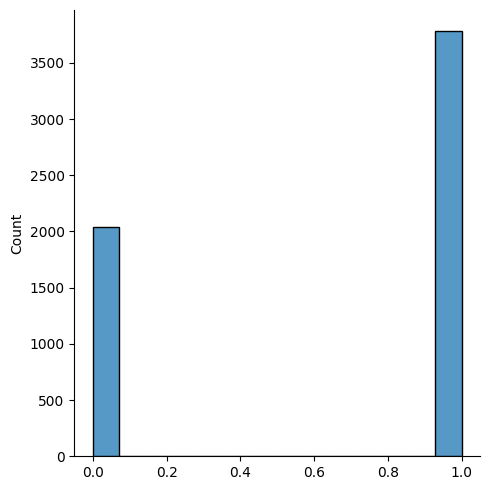

In [ ]:
import seaborn as sns
sns.displot(training_labels)

[ 638 4716 4290  266 1693 4202]


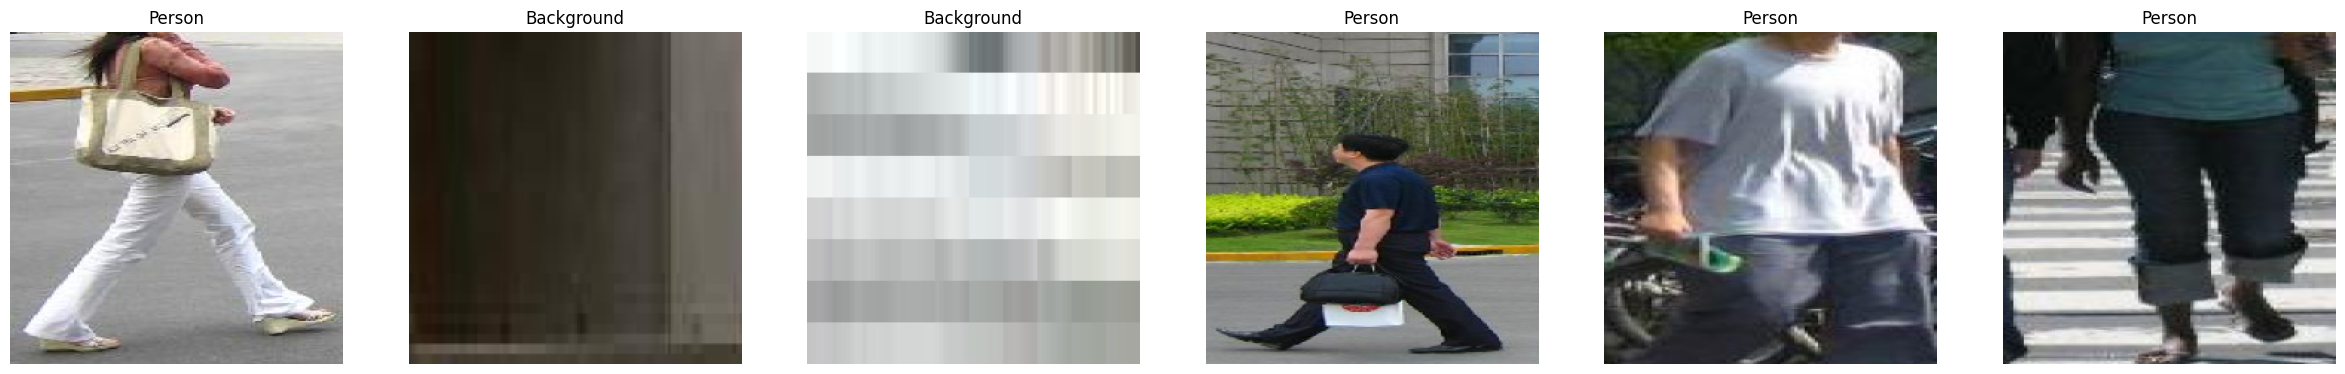

In [ ]:
indices = np.random.randint(len(training_images), size=(6))
print(indices)
fig, axes = plt.subplots(1, 6, figsize=(30, 5))
for i in range(6):
    axes[i].imshow(training_images[indices[i]])
    axes[i].axis('off')
    axes[i].set_title("Person" if training_labels[indices[i]] == 1 else "Background")

plt.show()